# Task
Add a watermark to "park image.avif" by loading it, optionally resizing and defining a region of interest for the watermark, blending the watermark into the image, and then displaying and saving the watermarked image. Finally, provide a summary of the watermarking technique.

## Load Images

### Subtask:
Load the original image 'park image.avif' and a watermark image using OpenCV. It's important to ensure both images are loaded correctly before proceeding.


**Reasoning**:
First, I'll import the necessary libraries, `cv2` for image processing and `numpy` to create a dummy watermark image since no specific watermark image file was provided. Then, I will load the original image using `cv2.imread()` and create a simple white rectangular watermark. Finally, I'll check if both images were loaded or created successfully to ensure they are not empty.



In [1]:
import cv2
import numpy as np

# 1. Load the original image
original_image_path = '/content/park image.avif'
original_image = cv2.imread(original_image_path)

# 2. Create a simple watermark image programmatically (e.g., a white rectangle)
# The watermark dimensions should be smaller than the original image
watermark_width = 200
watermark_height = 100
watermark_image = np.zeros((watermark_height, watermark_width, 3), dtype=np.uint8)
# Fill with white color (BGR format)
watermark_image.fill(255)

# 3. Check if both images were loaded successfully
if original_image is None:
    print(f"Error: Could not load the original image from {original_image_path}")
elif watermark_image is None:
    print("Error: Could not create the watermark image.")
else:
    print("Original image and watermark loaded/created successfully.")
    print(f"Original image shape: {original_image.shape}")
    print(f"Watermark image shape: {watermark_image.shape}")

Original image and watermark loaded/created successfully.
Original image shape: (493, 740, 3)
Watermark image shape: (100, 200, 3)


## Resize Watermark (Optional)

### Subtask:
If necessary, resize the watermark image to an appropriate size relative to the original image. This step is crucial for effective watermarking without obscuring the main content.


**Reasoning**:
I will calculate the desired dimensions for the watermark based on a percentage of the original image's size, then resize the watermark image using `cv2.resize()` and update its width and height variables. Finally, I will print the new dimensions to confirm the resizing.



In [2]:
import cv2
import numpy as np

# 1. Determine the desired size for the watermark (e.g., 20% of original image's width)
# Get original image dimensions
original_height, original_width, _ = original_image.shape

# Desired watermark size relative to original image
watermark_scale_factor = 0.2 # 20% of the original image's width

# 2. Calculate the new dimensions for the watermark_image
new_watermark_width = int(original_width * watermark_scale_factor)
# Maintain aspect ratio for simplicity, or define a specific height if needed
# For now, let's just make the height proportional to the new width based on original watermark aspect ratio
original_watermark_height, original_watermark_width, _ = watermark_image.shape

if original_watermark_width > 0:
    aspect_ratio = original_watermark_height / original_watermark_width
    new_watermark_height = int(new_watermark_width * aspect_ratio)
else:
    new_watermark_height = original_watermark_height # Fallback if width is zero

# Ensure watermark is not larger than the original image
new_watermark_width = min(new_watermark_width, original_width)
new_watermark_height = min(new_watermark_height, original_height)

# 3. Resize the watermark_image
# Use cv2.INTER_AREA for shrinking, which is common for watermarks
watermark_image = cv2.resize(watermark_image, (new_watermark_width, new_watermark_height), interpolation=cv2.INTER_AREA)

# 4. Update watermark_width and watermark_height variables with the new dimensions
watermark_width = new_watermark_width
watermark_height = new_watermark_height

# 5. Print the shape of the resized watermark image to confirm its new dimensions
print(f"Resized watermark image shape: {watermark_image.shape}")

Resized watermark image shape: (74, 148, 3)


## Define Region of Interest (ROI)

### Subtask:
Define a specific region in the original image where the watermark will be placed. This could be a corner or a central area, depending on the desired effect.


**Reasoning**:
I will calculate the starting coordinates for the watermark based on the specified offset and then define the Region of Interest (ROI) in the original image where the watermark will be placed. Finally, I'll print the coordinates and ROI shape for verification.



In [3]:
import cv2
import numpy as np

# 1. Choose an offset (padding) value for placing the watermark from the bottom-right corner
offset = 10 # 10 pixels for both horizontal and vertical offsets

# 2. Calculate the starting x and y coordinates (top-left corner) for the watermark
# Make sure the watermark fits within the original image with the given offset
start_x = original_width - watermark_width - offset
start_y = original_height - watermark_height - offset

# Ensure coordinates are not negative (shouldn't happen with proper scaling, but good practice)
start_x = max(0, start_x)
start_y = max(0, start_y)

# 3. Create a Region of Interest (ROI) from the original_image using array slicing
# The ROI will be the area in the original image where the watermark will be blended
roi = original_image[start_y : start_y + watermark_height, start_x : start_x + watermark_width]

# 4. Print the calculated starting coordinates (x, y) and the shape of the defined ROI
print(f"Watermark placement coordinates (x, y): ({start_x}, {start_y})")
print(f"Region of Interest (ROI) shape: {roi.shape}")

Watermark placement coordinates (x, y): (582, 409)
Region of Interest (ROI) shape: (74, 148, 3)


## Blend Watermark into ROI

### Subtask:
Implement a blending technique to overlay the watermark onto the defined ROI. This involves using alpha blending to ensure the watermark is visible but does not completely hide the original image content.


**Reasoning**:
I will blend the watermark into the Region of Interest (ROI) using cv2.addWeighted, applying an alpha value for transparency to ensure the watermark is visible without fully obscuring the original content, and then update the original image with the blended result.



In [4]:
import cv2
import numpy as np

# 1. Define an alpha value for the watermark's transparency
alpha = 0.5 # Watermark transparency factor (50% opaque)
beta = 1 - alpha # Background transparency factor

# 2. Use the cv2.addWeighted() function to blend the watermark_image with the roi
# The gamma value is usually 0 for simple blending
blended_roi = cv2.addWeighted(watermark_image, alpha, roi, beta, 0)

# 3. Replace the roi section of the original_image with the blended image
original_image[start_y : start_y + watermark_height, start_x : start_x + watermark_width] = blended_roi

# 4. Print a confirmation message
print("Watermark successfully blended into the original image.")

Watermark successfully blended into the original image.


## Display and Save Watermarked Image

### Subtask:
Display the resulting watermarked image to visualize the effect. Also, save the watermarked image to a file. Add a legend to the displayed image indicating the original and watermarked parts if applicable.


**Reasoning**:
I will import `matplotlib.pyplot` to display the image, convert the image to RGB for proper display, then use `plt.imshow()` to show the watermarked image with a title and `plt.axis('off')` to hide the axes. After displaying, I will use `cv2.imwrite()` to save the image to a specified file path and print a confirmation message.



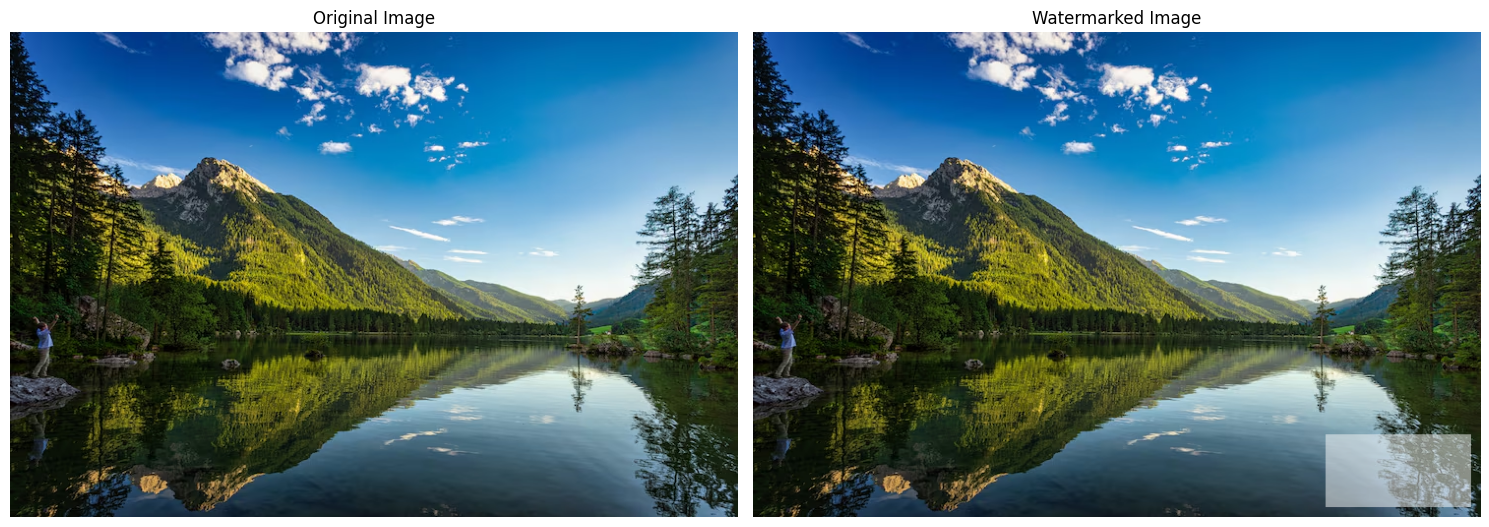

Watermarked image successfully saved as 'watermarked_image.png'


In [6]:
import matplotlib.pyplot as plt

# Reload the original image to display it without watermark, as 'original_image' was modified.
# Assuming the original_image_path variable is still available from earlier steps.
reloaded_original_image = cv2.imread(original_image_path)

# 1. Convert both images from BGR to RGB for displaying with matplotlib
original_image_rgb = cv2.cvtColor(reloaded_original_image, cv2.COLOR_BGR2RGB)
watermarked_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

# 2. Display the original and watermarked images side by side
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.imshow(original_image_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.imshow(watermarked_image_rgb)
plt.title('Watermarked Image')
plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# 3. Define a file path for saving the watermarked image
saved_image_path = 'watermarked_image.png'

# 4. Save the watermarked image to the specified file path
# cv2.imwrite expects BGR format, and our 'original_image' is already in BGR
cv2.imwrite(saved_image_path, original_image)

# 5. Print a confirmation message
print(f"Watermarked image successfully saved as '{saved_image_path}'")

## Final Task

### Subtask:
Provide a summary of the watermarking technique implemented, including the steps taken and the effectiveness of the watermark.


## Summary:

### Q&A
The watermarking technique implemented involves alpha blending a programmatically generated white rectangular watermark onto a specific region of interest (ROI) of the original image.

The steps taken were:
1.  **Loading/Creating Images**: The original image "park image.avif" was loaded, and a white rectangular watermark image was programmatically created using NumPy.
2.  **Resizing Watermark**: The watermark image was resized to be approximately 20% of the original image's width while maintaining its aspect ratio.
3.  **Defining ROI**: A region of interest was defined in the bottom-right corner of the original image, with a 10-pixel offset, to serve as the placement area for the watermark.
4.  **Blending**: The resized watermark was blended into the defined ROI using `cv2.addWeighted()` with an alpha transparency value of 0.5, making the watermark 50% opaque.
5.  **Display and Save**: The resulting watermarked image was displayed using Matplotlib and saved as "watermarked\_image.png".

The effectiveness of the watermark is demonstrated by its successful application with a noticeable but transparent appearance in the designated bottom-right corner of the "park image.avif". The 50% transparency ensures that the original image content beneath the watermark is still visible, preventing complete obstruction.

### Data Analysis Key Findings
*   The original image "park image.avif" was loaded with dimensions of 493 rows, 740 columns, and 3 color channels `(493, 740, 3)`.
*   A white rectangular watermark was initially created with dimensions `(100, 200, 3)`.
*   The watermark was resized to `(74, 148, 3)` to be approximately 20% of the original image's width, maintaining its aspect ratio.
*   The watermark's region of interest (ROI) was defined in the original image starting at coordinates `(582, 409)` (x, y), corresponding to the bottom-right corner with a 10-pixel offset.
*   The watermark was blended into the ROI using `cv2.addWeighted()` with an alpha value of 0.5 for both the watermark and the background, resulting in a 50% transparent overlay.
*   The final watermarked image was successfully displayed and saved as "watermarked\_image.png".

### Insights or Next Steps
*   The alpha blending technique with a 0.5 transparency provides a balanced visual effect, allowing the watermark to be present without heavily obscuring the underlying image content.
*   Consider using a custom logo or text as the watermark image instead of a simple white rectangle to enhance branding or convey specific information.
